# (IIP314W-2) [2026-T2] OPTIMIZACIÓN APLICADA A NEGOCIOS
## Ayudantía 7 — Pauta: Modelamiento con Big-M, análisis de sensibilidad y precios sombra

---

**Profesor:** Rodrigo Trigo Vilches

**Ayudante:** Vicente Ramírez

**Fecha:** 5 de agosto de 2026

**Universidad del Desarrollo**

---

## Objetivos

- Formular un modelo **entero-mixto (MIP)** compacto que combine cuatro estructuras clásicas: **proporciones** de mezcla, **balance de inventario**, una **restricción de activación Big-M** y capacidad de transporte en **masa y volumen**.
- Resolverlo en `gurobipy` e interpretar el plan en términos de negocio.
- Hacer **análisis de sensibilidad de los recursos**: precios sombra, holgura complementaria y **rango de validez**.
- Entender por qué un MIP **no tiene precios sombra** y cómo se obtienen **fijando la variable binaria en su valor óptimo** para transformarlo en un LP.
- Distinguir cuándo el precio sombra **responde** una pregunta de negocio y cuándo hay que **volver a resolver**.

> **Conexión con las clases.** En las Clases 22 y 27 el profesor construyó el dual, el teorema de holguras complementarias y el análisis de sensibilidad ($\partial z^*/\partial b_i$, rangos). En la Ayudantía 6 leímos los precios sombra **en el tableau óptimo**. Aquí hacemos lo mismo sobre un modelo con una **binaria**, donde el tableau ya no basta.

## Sección 0 — Repaso

### 0.1 Proporciones de mezcla

Para exigir que el origen $g$ no aporte más de una fracción $\bar\alpha_{gi}$ del blend $i$, la tentación es escribir

$$\frac{x_{gi}}{\sum_{g'} x_{g'i}}\le\bar\alpha_{gi},$$

que **no es lineal** (variable en el denominador) y además está indefinida si no se produce nada. Se **multiplica cruzado**:

$$\boxed{\;x_{gi}\;\le\;\bar\alpha_{gi}\sum_{g'} x_{g'i}\;}$$

Lineal, y si el blend no se produce fuerza correctamente $x_{gi}=0$.

### 0.2 Balance de inventario

$$\text{inventario al cierre de }t\;=\;\text{inventario al cierre de }t-1\;+\;\text{producción}_t\;-\;\text{despachos}_t$$

Es una **igualdad**, y el primer periodo usa el **dato** $r^0_i$ (la variable $r_{i,0}$ no existe).

### 0.3 Activación Big-M

Queremos: *"la tostadora rinde $K$ kg por semana; se puede sumar un turno extra de $K^{ex}$ kg, pero habilitarlo cuesta $F$"*. Con $y_t\in\{0,1\}$:

$$\boxed{\;\sum_{g}\sum_i x_{git}\;\le\;K+M\,y_t\;}\qquad\text{y en la objetivo }\;-F\,y_t$$

- $y_t=0$ ⟹ el tope es $K$: el turno está apagado.
- $y_t=1$ ⟹ el tope es $K+M$: hay que elegir $M$ **igual a la capacidad extra real**, $M=K^{ex}$.

La lógica *"si uso, pago"* la induce el óptimo: como $F>0$, el modelo nunca pone $y_t=1$ sin necesitarlo.

**¿Y si ponemos $M=10^9$?** La restricción sigue siendo *correcta* pero la **relajación lineal** se arruina: el LP puede tostar 3.000 kg con $y_t=3\cdot10^{-6}$ y pagar casi nada de costo fijo. La cota del *branch and bound* queda floja y el modelo se vuelve lento. **Regla: el $M$ más chico que siga siendo válido.**

### 0.4 Masa y volumen: dos restricciones, no una

Un camión tiene **dos** límites y basta que uno se agote: kilos ($W$) y metros cúbicos ($V^{cam}$):

$$\sum_i v_{it}\le W\,\qquad\text{(masa)}\qquad\qquad \sum_i \nu_i\,v_{it}\le V^{cam}\qquad\text{(volumen)}$$

con $\nu_i$ el **volumen específico** [m³/kg]. Escribir solo una es un error clásico. Cuál de las dos aprieta **no lo decidimos nosotros**: lo dice el precio sombra.

### 0.5 Precios sombra, rango de validez y el problema de los MIP

Para un LP, el precio sombra de la restricción $i$ es su variable dual: $\pi_i=\partial z^*/\partial b_i$, el valor marginal de una unidad extra del recurso. Tres propiedades:

| Propiedad | Enunciado | Lectura de negocio |
|:--|:--|:--|
| **Holgura complementaria** | $\pi_i\cdot\text{Slack}_i=0$ | si sobra recurso no pago por más; si pago por más, es porque está agotado |
| **Rango de validez** | $\pi_i$ es constante solo mientras $b_i\in[b_i^{\text{low}},b_i^{\text{up}}]$ | el precio vale para **cambios chicos** |
| **Signo** | en un máximo, $\pi_i\ge0$ para una restricción $\le$ | relajar un techo nunca empeora |

**Un MIP no tiene precios sombra.** La dualidad es teoría de programación **lineal**: vive en el tableau del Simplex. Mientras haya binarias libres, $z^*(b)$ no es cóncava ni lineal por tramos y las duales no están definidas. La técnica estándar es en dos pasos:

1. Resolver el **MIP** y quedarse con el óptimo $y^*$ de la binaria.
2. **Fijar $y^*$** y tratarla como **dato**. Queda un **LP puro** en las variables continuas, con el mismo valor óptimo, y ahí sí hay duales: `.Pi`, `.Slack`, `.RC`, `.SARHSLow`, `.SARHSUp`.

En `gurobipy` esto se obtiene con `m.fixed()`, o reconstruyendo el modelo con $y^*$ como número.

> **Y la advertencia clave:** esos duales valen **manteniendo fija la decisión discreta**. Sirven para *"¿cuánto vale un m³ más de bodega?"*; **no** sirven para *"¿me conviene arrendar otro camión?"* o *"¿conviene habilitar el turno extra?"*, porque eso cambia $y$ o cambia el problema. Ahí hay que **volver a resolver**.

---

# Ejercicio — Tostaduría "Kütral Café"

### Contexto

**Kütral Café** es una tostaduría de especialidad que vende café en grano a cafeterías. Hay que planificar las próximas **tres semanas**.

Se compra café verde de dos orígenes, **arábica de Colombia** (COL) y **robusta de Vietnam** (VIE), a precio $c_g$ por kilo. Con ellos se preparan dos blends: **Espresso Cumbre** (ESP) e **Intenso Patagón** (INT). Cada blend es una **receta**: la robusta —más barata— no puede superar una fracción $\bar\alpha_{gi}$ de la mezcla, o el perfil de taza se pierde.

La **tostadora** procesa hasta $K$ kg por semana. Si no alcanza, se puede **habilitar un turno extra de noche** que agrega $K^{ex}$ kg, pero cuesta un **fijo $F$** por semana (personal nocturno, supervisión). Se decide semana a semana.

Lo producido y no despachado queda en la **bodega**, limitada por **volumen** $V^{bod}$ (m³), no por peso: el espacio es lo escaso. Almacenar cuesta $h$ por kg y por semana.

Los despachos salen en camión: hasta $W$ kg **y** $V^{cam}$ m³ por camión, a un costo $ct$ por camión-semana. Aquí importa el **envase**: el Espresso Cumbre va en **bolsas de 250 g** para góndola y el Intenso Patagón en **sacos de 1 kg** para cafeterías, así que el ESP ocupa **casi el doble de volumen por kilo** que el INT.

Cada semana hay un **compromiso contractual** $\underline d_{it}$ que debe cumplirse y una **demanda máxima** $\bar d_{it}$ que el mercado absorbe. Se vende a precio $pr_i$.

**Objetivo:** maximizar el margen de las tres semanas (ingresos − café verde − costo fijo del turno extra − almacenamiento − transporte).

### Conjuntos y parámetros

| Símbolo | Descripción |
|:--|:--|
| $\mathcal{G}=\{\text{COL},\text{VIE}\}$ | orígenes de café verde (índice $g$) |
| $\mathcal{I}=\{\text{ESP},\text{INT}\}$ | blends (índice $i$) |
| $\mathcal{T}=\{1,2,3\}$ | semanas (índice $t$) |

| Símbolo | Significado | Unidad |
|:--|:--|:--|
| $c_g$ | costo del café verde del origen $g$ | \$/kg |
| $pr_i$ | precio de venta del blend $i$ | \$/kg |
| $\bar\alpha_{gi}$ | fracción máxima del origen $g$ en la receta del blend $i$ | — |
| $K$ | capacidad de tostado del turno normal | kg/semana |
| $K^{ex}$ | capacidad adicional del turno extra | kg/semana |
| $F$ | costo fijo de habilitar el turno extra | \$/semana |
| $h$ | costo de almacenamiento | \$/(kg·semana) |
| $V^{bod}$ | volumen de la bodega | m³ |
| $\nu_i$ | volumen específico del blend $i$ (según su envase) | m³/kg |
| $W,\ V^{cam}$ | capacidad de un camión en masa y en volumen | kg, m³ |
| $nc_t$ | camiones disponibles en la semana $t$ | camiones |
| $ct$ | costo por camión-semana | \$ |
| $\underline d_{it},\ \bar d_{it}$ | compromiso contractual y demanda máxima | kg |
| $r^0_i$ | inventario inicial | kg |

### Datos de la instancia

Costos y precios en **\$ mil**.

| | COL | VIE | | | ESP | INT |
|:--|--:|--:|:--|:--|--:|--:|
| $c_g$ (\$ mil/kg) | 6,0 | 3,5 | | $pr_i$ (\$ mil/kg) | 14,0 | 11,0 |
| $\bar\alpha_{g,\text{ESP}}$ | 1,00 | **0,25** | | $\nu_i$ (m³/kg) | **0,0045** | **0,0025** |
| $\bar\alpha_{g,\text{INT}}$ | 1,00 | **0,60** | | envase | bolsas 250 g | sacos 1 kg |

| Escalar | $K$ | $K^{ex}$ | $F$ | $h$ | $V^{bod}$ | $W$ | $V^{cam}$ | $ct$ | $nc_t$ |
|:--|--:|--:|--:|--:|--:|--:|--:|--:|--:|
| valor | 1.500 | 400 | 500 | 0,10 | 1,1 | 2.400 | 7,0 | 600 | 1 |

| Demanda (kg) | $t=1$ | $t=2$ | $t=3$ |
|:--|--:|--:|--:|
| $\bar d_{\text{ESP},t}$ (máxima) | 700 | 1.200 | 1.100 |
| $\bar d_{\text{INT},t}$ (máxima) | 300 | 600 | 1.200 |
| $\underline d_{\text{ESP},t}$ (compromiso) | 280 | 480 | 440 |
| $\underline d_{\text{INT},t}$ (compromiso) | 120 | 240 | 480 |

Inventario inicial $r^0_i=0$.

### Se pide

**Parte A — Formulación (a mano, sin números).**

1. Defina las **variables de decisión** con su dominio, la **función objetivo** y las **seis familias de restricciones** en notación de sumatorias con su $\forall$.
2. Justifique el valor de $M$ en la restricción de activación. ¿Qué pasaría con $M=10^9$?
3. ¿Por qué la restricción de proporciones **no** se escribe como un cociente? ¿Por qué la masa y el volumen del camión son **dos** restricciones y no una?

**Parte B — Resolución en Gurobi.**

4. Implemente el modelo y resuélvalo. Reporte el margen óptimo, en qué semanas se habilita el turno extra, el plan de producción y despacho, y la trayectoria del inventario.
5. **Interprete el plan**: ¿por qué se produce por adelantado y se guarda inventario? ¿por qué el turno extra se habilita solo en una semana? ¿queda demanda sin atender, y quién la está bloqueando?

**Parte C — Análisis de sensibilidad.**

6. El modelo es un MIP. **Fije la binaria en su óptimo** para obtener el LP equivalente; verifique que el valor óptimo coincide y que ya no es un MIP.
7. Construya la tabla de **precios sombra** de los cuatro recursos (tostado, bodega, masa del camión, volumen del camión) con holgura, lado derecho y **rango de validez**. Verifique la **holgura complementaria**.
8. Los dos recursos activos de la semana 3 se pueden calcular **a mano**: escriba las dos restricciones duales activas (una por blend) y resuelva el sistema $2\times2$. Compare con lo que reporta Gurobi.
9. Interprete el precio sombra de la **bodega**: descompóngalo en los parámetros del problema (debe cuadrar exacto).
10. ¿Cuánto vale ampliar la bodega en $0{,}05$ m³? ¿Y en $0{,}4$ m³? ¿Y agrandar la caja del camión en $0{,}1$ m³? ¿Y en $1{,}0$ m³? **Compare la predicción del precio sombra con el resultado de volver a resolver** y explique con el rango de validez. Grafique $z^*(b)$ para ambos recursos.
11. ¿Por qué el precio sombra de la **masa** del camión es cero? ¿Qué le recomendaría a la empresa si le ofrecen un camión con 600 kg más de carga útil?
12. Arrendar un **segundo camión** en la semana 3 cuesta $ct=600$. ¿Conviene? ¿Puede responderlo con el precio sombra? Resuelva de nuevo y compare.
13. ¿Conviene habilitar el turno extra en las semanas 1 o 2? Responda **forzando la binaria** y comparando, y explique por qué esta pregunta no se puede responder con los duales.

---

# Solución

## Parte A — Formulación

### Variables de decisión

| Variable | Descripción | Dominio |
|:--|:--|:--|
| $x_{git}$ | kg del origen $g$ que entran a la mezcla del blend $i$ en la semana $t$ | $\ge0$ |
| $v_{it}$ | kg del blend $i$ despachados y vendidos en $t$ | $\ge0$ |
| $r_{it}$ | inventario del blend $i$ al cierre de $t$ | $\ge0$ |
| $y_t$ | $1$ si se habilita el turno extra de tostado en $t$ | $\in\{0,1\}$ |

Notar que **no hace falta** una variable de producción: lo producido del blend $i$ en $t$ es $\sum_g x_{git}$.

### Función objetivo

$$\max\;\; \underbrace{\sum_{i}\sum_{t} pr_i\,v_{it}}_{\text{ingresos}}\;-\;\underbrace{\sum_g\sum_i\sum_t c_g\,x_{git}}_{\text{café verde}}\;-\;\underbrace{\sum_t F\,y_t}_{\text{turno extra}}\;-\;\underbrace{\sum_i\sum_t h\,r_{it}}_{\text{almacenamiento}}\;-\;\underbrace{\sum_t ct\,nc_t}_{\text{transporte}}$$

### Restricciones

$$
\begin{aligned}
x_{git} &\le \bar\alpha_{gi}\sum_{g'\in\mathcal G} x_{g'it} && \forall g,i,t &&\text{(receta / proporción)}\\[3pt]
r_{it} &= r_{i,t-1} + \sum_{g} x_{git} - v_{it} && \forall i,t &&\text{(balance de inventario; } r_{i,0}=r^0_i)\\[3pt]
\sum_{g}\sum_{i} x_{git} &\le K + M\,y_t && \forall t &&\textbf{(activación Big-M del turno extra)}\\[3pt]
\sum_{i} \nu_i\,r_{it} &\le V^{bod} && \forall t &&\text{(volumen de bodega)}\\[3pt]
\sum_{i} v_{it} &\le W\,nc_t && \forall t &&\text{(masa del camión)}\\[3pt]
\sum_{i} \nu_i\,v_{it} &\le V^{cam}\,nc_t && \forall t &&\text{(volumen del camión)}\\[3pt]
\underline d_{it}\;\le\; &v_{it}\;\le\;\bar d_{it} && \forall i,t &&\text{(compromiso y demanda máxima: cotas)}\\[3pt]
x,v,r&\ge0,\qquad y_t\in\{0,1\}
\end{aligned}
$$

Los compromisos y la demanda máxima se escriben como **cotas de la variable** ($lb$ y $ub$), no como restricciones: es lo mismo y deja el modelo más limpio.

### Comentarios (preguntas 2 y 3)

**El valor de $M$.** $M$ debe ser una **cota superior válida** de la capacidad adicional que el turno extra puede aportar. Aquí ese dato existe y es exactamente $K^{ex}=400$: la tostadora en turno de noche no puede hacer más que eso. Entonces $M=K^{ex}$, y la restricción se lee $\sum\sum x_{git}\le K+K^{ex}y_t$.

Con $M=10^9$ la formulación **sigue siendo correcta** para valores enteros de $y_t$, pero la **relajación lineal** se degrada: el LP del nodo raíz puede tostar, digamos, $3.000$ kg poniendo $y_t=3\cdot10^{-6}$ y pagando $F\cdot3\cdot10^{-6}\approx0$ de costo fijo. La cota superior del *branch and bound* queda tan floja que el árbol crece muchísimo, y además aparecen problemas numéricos. **El $M$ más chico que siga siendo válido siempre es el mejor.**

**Las proporciones.** $x_{gi}/\sum_{g'}x_{g'i}\le\bar\alpha_{gi}$ es **no lineal** (variable en el denominador) y está **indefinida** cuando no se produce el blend. Multiplicando cruzado se arreglan las dos cosas a la vez.

**Masa y volumen.** Son dos límites **físicamente independientes** del mismo camión y basta que uno se agote. Con $\nu_{\text{ESP}}=0{,}0045$, los $7$ m³ de la caja se llenan con apenas $1.556$ kg de Espresso Cumbre, muy por debajo de los $2.400$ kg de carga útil; con Intenso Patagón, en cambio, caben $2.800$ kg de volumen pero el peso corta antes. **Según la mezcla que se despache, aprieta una u otra** — razón de más para escribir las dos y dejar que el modelo decida.

---

## Parte B — Resolución en Gurobi

Los datos van en un **diccionario** y el modelo en una **función**: así el mismo código sirve para el MIP, para el LP con la binaria fija y para los escenarios *what if* de la Parte C.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB, quicksum

### B.0 — Datos

In [2]:
def datos():
    """Instancia: 2 origenes x 2 blends x 3 semanas. Costos y precios en $ mil."""
    d = {}
    d["G"] = ["COL", "VIE"]                       # origenes de cafe verde
    d["I"] = ["ESP", "INT"]                       # blends
    d["T"] = [1, 2, 3]                            # semanas

    d["c"]  = {"COL": 6.0, "VIE": 3.5}            # costo del cafe verde ($ mil/kg)
    d["pr"] = {"ESP": 14.0, "INT": 11.0}          # precio de venta ($ mil/kg)
    d["amax"] = {("COL","ESP"): 1.00, ("VIE","ESP"): 0.25,   # fraccion maxima en la receta
                 ("COL","INT"): 1.00, ("VIE","INT"): 0.60}

    d["K"], d["Kex"], d["F"] = 1500, 400, 500     # tostado: normal, turno extra, costo fijo
    d["h"] = 0.10                                 # almacenamiento ($ mil/kg-semana)
    d["Vbod"] = 1.1                               # volumen de bodega (m3)
    d["vol"] = {"ESP": 0.0045, "INT": 0.0025}     # volumen especifico (m3/kg) segun envase

    d["W"], d["Vcam"], d["ct"] = 2400, 7.0, 600   # camion: kg, m3, $ mil por camion-semana
    d["nc"] = {1: 1, 2: 1, 3: 1}                  # camiones disponibles por semana (DATO)

    d["dmax"] = {("ESP",1):700, ("ESP",2):1200, ("ESP",3):1100,
                 ("INT",1):300, ("INT",2):600,  ("INT",3):1200}
    d["dmin"] = {k: round(0.4*val) for k, val in d["dmax"].items()}
    d["r0"] = {"ESP": 0.0, "INT": 0.0}
    return d

D = datos()
print("M = Kex =", D["Kex"], "kg   (la cota valida mas chica)")
print("Un camion se llena con", round(D["Vcam"]/D["vol"]["ESP"]), "kg de ESP  o",
      round(D["Vcam"]/D["vol"]["INT"]), "kg de INT  (carga util:", D["W"], "kg)")

M = Kex = 400 kg   (la cota valida mas chica)
Un camion se llena con 1556 kg de ESP  o 2800 kg de INT  (carga util: 2400 kg)


### B.1 — El modelo

Una sola función construye el **MIP** o el **LP con $y$ fija**, según el argumento `ybar`. Cada familia de restricciones lleva **nombre**, porque en la Parte C vamos a pedir sus duales por nombre.

In [3]:
def construir_modelo(d, ybar=None, **cambios):
    """MIP de Kutral Cafe.

    ybar=None       -> MIP (y_t binaria).
    ybar={t: 0/1}   -> LP puro: y_t entra como DATO, el costo fijo es una constante
                       y el lado derecho del tostado queda numerico (K + Kex*y*_t).
    **cambios       -> sobrescribe parametros para los escenarios "what if".
    """
    d = {**d, **cambios}
    G, I, T = d["G"], d["I"], d["T"]
    t0 = T[0]

    m = gp.Model("kutral")
    m.Params.OutputFlag = 0
    m.Params.MIPGap = 0.0        # optimo exacto: los experimentos deben ser comparables

    x = m.addVars(G, I, T, name="x")                                  # kg de g en el blend i
    v = m.addVars(I, T, lb=d["dmin"], ub=d["dmax"], name="v")          # despachos (con cotas)
    r = m.addVars(I, T, name="r")                                     # inventario

    if ybar is None:
        y = m.addVars(T, vtype=GRB.BINARY, name="y")
        costo_fijo = quicksum(d["F"]*y[t] for t in T)
    else:
        y = ybar                                                       # numeros, no variables
        costo_fijo = sum(d["F"]*y[t] for t in T)

    m.setObjective(quicksum(d["pr"][i]*v[i,t] for i in I for t in T)          # ingresos
                   - quicksum(d["c"][g]*x[g,i,t] for g in G for i in I for t in T)  # cafe verde
                   - costo_fijo                                               # turno extra
                   - quicksum(d["h"]*r[i,t] for i in I for t in T)            # almacenamiento
                   - sum(d["ct"]*d["nc"][t] for t in T),                      # transporte
                   GRB.MAXIMIZE)

    # (1) receta: la robusta no puede pasar de amax en cada blend
    m.addConstrs((x[g,i,t] <= d["amax"][g,i]*quicksum(x[gg,i,t] for gg in G)
                  for g in G for i in I for t in T), "receta")
    # (2) balance de inventario
    m.addConstrs((r[i,t] == (d["r0"][i] if t == t0 else r[i,t-1])
                  + quicksum(x[g,i,t] for g in G) - v[i,t]
                  for i in I for t in T), "inventario")
    # (3) capacidad de tostado con ACTIVACION Big-M del turno extra
    m.addConstrs((quicksum(x[g,i,t] for g in G for i in I) <= d["K"] + d["Kex"]*y[t]
                  for t in T), "tostado")
    # (4) volumen de bodega
    m.addConstrs((quicksum(d["vol"][i]*r[i,t] for i in I) <= d["Vbod"]
                  for t in T), "bodega")
    # (5) y (6) camion: masa Y volumen
    m.addConstrs((quicksum(v[i,t] for i in I) <= d["W"]*d["nc"][t]
                  for t in T), "peso")
    m.addConstrs((quicksum(d["vol"][i]*v[i,t] for i in I) <= d["Vcam"]*d["nc"][t]
                  for t in T), "volumen")

    m._var = dict(x=x, v=v, r=r, y=y); m._d = d
    m.update()
    return m


def resolver(d, **cambios):
    m = construir_modelo(d, **cambios); m.optimize(); return m

### B.2 — Resolución (pregunta 4)

In [4]:
m = resolver(D)
V, G, I, T = m._var, D["G"], D["I"], D["T"]
ystar = {t: int(round(V["y"][t].X)) for t in T}

print(f"Estado: {m.Status} (2 = OPTIMAL)")
print(f"Margen optimo = {m.ObjVal:,.2f}  ($ mil)")
print(f"{m.NumVars} variables ({m.NumIntVars} binarias)  |  {m.NumConstrs} restricciones")
print(f"\nTurno extra habilitado:  y* = {ystar}")

Set parameter Username


Academic license - for non-commercial use only - expires 2027-06-10


Estado: 2 (2 = OPTIMAL)
Margen optimo = 35,158.25  ($ mil)
27 variables (3 binarias)  |  30 restricciones

Turno extra habilitado:  y* = {1: 0, 2: 0, 3: 1}


### B.3 — El plan óptimo

In [5]:
print(f"{'':10}{'tostado':>12}{'tope':>8}{'despacho':>11}{'tope kg':>9}"
      f"{'m3':>8}{'tope m3':>9}{'bodega':>9}{'tope':>7}")
for t in T:
    tostado = sum(V['x'][g,i,t].X for g in G for i in I)
    kg  = sum(V['v'][i,t].X for i in I)
    m3  = sum(D["vol"][i]*V['v'][i,t].X for i in I)
    bod = sum(D["vol"][i]*V['r'][i,t].X for i in I)
    print(f"semana {t:<3}{tostado:>12.0f}{D['K']+D['Kex']*ystar[t]:>8}{kg:>11.0f}"
          f"{D['W']*D['nc'][t]:>9}{m3:>8.3f}{D['Vcam']*D['nc'][t]:>9.1f}{bod:>9.3f}{D['Vbod']:>7.1f}")

print("\nProduccion y despacho por blend (kg):")
print(f"{'':8}" + "".join(f"{'t'+str(t):>22}" for t in T))
print(f"{'':8}" + "".join(f"{'prod':>10}{'venta/max':>12}" for t in T))
for i in I:
    fila = f"{i:<8}"
    for t in T:
        fila += f"{sum(V['x'][g,i,t].X for g in G):>10.0f}"
        fila += f"{str(round(V['v'][i,t].X))+'/'+str(D['dmax'][i,t]):>12}"
    print(fila)

print("\nInventario al cierre (kg):")
for i in I:
    print(f"  {i:<6}" + "".join(f"{V['r'][i,t].X:>9.0f}" for t in T))

print("\nReceta efectiva (fraccion de robusta VIE):")
for i in I:
    print(f"  {i:<6}" + "".join(
        f"{V['x']['VIE',i,t].X/max(1e-9, sum(V['x'][g,i,t].X for g in G)):>9.2f}" for t in T)
        + f"   (tope amax = {D['amax']['VIE',i]})")

               tostado    tope   despacho  tope kg      m3  tope m3   bodega   tope
semana 1          1440    1500       1000     2400   3.900      7.0    1.100    1.1
semana 2          1500    1500       1800     2400   6.900      7.0    0.630    1.1
semana 3          1900    1900       2040     2400   7.000      7.0    0.000    1.1

Produccion y despacho por blend (kg):
                            t1                    t2                    t3
              prod   venta/max      prod   venta/max      prod   venta/max
ESP            700     700/700      1340   1200/1200       810    950/1100
INT            740     300/300       160     600/600      1090   1090/1200

Inventario al cierre (kg):
  ESP           0      140        0
  INT         440        0        0

Receta efectiva (fraccion de robusta VIE):
  ESP        0.25     0.25     0.25   (tope amax = 0.25)
  INT        0.60     0.60     0.60   (tope amax = 0.6)


**Interpretación del plan (pregunta 5).**

- **Se produce por adelantado y se guarda inventario** porque la capacidad de tostado ($1.500$ kg/semana) es plana pero la demanda crece: $1.000$ kg en $t_1$, $1.800$ en $t_2$ y $2.300$ en $t_3$. En $t_1$ sobra capacidad, así que el modelo tuesta $1.440$ kg —más de lo que despacha— y guarda **$440$ kg de Intenso Patagón** para $t_2$. Y guarda **INT y no ESP**: en un metro cúbico caben $400$ kg de INT contra solo $222$ kg de ESP, así que la bodega, que se mide en volumen, rinde casi el doble llenándola con el blend compacto. La bodega queda **llena al 100 %** al cierre de $t_1$.

- **El turno extra se habilita solo en $t_3$** porque su costo fijo ($F=500$) solo se justifica donde no hay alternativa. En $t_1$ y $t_2$ la capacidad normal alcanza (en $t_2$ ayudada por el inventario que viene de $t_1$); en $t_3$ la demanda es de $2.300$ kg contra un tope de $1.500$, y ya no queda margen para producir antes: la bodega está tope.

- **Sí queda demanda sin atender, y el culpable es el camión.** En $t_3$ el mercado pedía $1.100$ kg de ESP y $1.200$ de INT, pero se despachan $950$ y $1.090$. El camión sale con **$7{,}000$ de $7{,}0$ m³** — la caja **exactamente llena**— y todavía con **$360$ kg de holgura de peso** ($2.040$ de $2.400$ kg). Es el **volumen** el que corta las ventas, no el peso ni la tostadora. Si hubiéramos escrito solo la restricción de kilos, el plan habría prometido despachar $2.300$ kg que físicamente no caben.

- La **receta** está siempre en su tope: la robusta entra al $25\,\%$ en el ESP y al $60\,\%$ en el INT, los máximos permitidos. Es esperable: la robusta cuesta $3{,}5$ contra $6{,}0$ del colombiano, así que el modelo abarata la mezcla hasta el último punto que la receta autoriza.

### B.4 — Verificación de factibilidad

In [6]:
tol = 1e-6
ok_rec = all(V['x'][g,i,t].X <= D["amax"][g,i]*sum(V['x'][gg,i,t].X for gg in G) + tol
             for g in G for i in I for t in T)
ok_inv = all(abs(V['r'][i,t].X - ((D["r0"][i] if t == T[0] else V['r'][i,t-1].X)
             + sum(V['x'][g,i,t].X for g in G) - V['v'][i,t].X)) < 1e-5 for i in I for t in T)
ok_big = all(sum(V['x'][g,i,t].X for g in G for i in I) <= D["K"] + D["Kex"]*ystar[t] + tol
             for t in T)
ok_bod = all(sum(D["vol"][i]*V['r'][i,t].X for i in I) <= D["Vbod"] + tol for t in T)
ok_cam = all(sum(V['v'][i,t].X for i in I) <= D["W"]*D["nc"][t] + tol
             and sum(D["vol"][i]*V['v'][i,t].X for i in I) <= D["Vcam"]*D["nc"][t] + tol
             for t in T)
ok_dem = all(D["dmin"][i,t] - tol <= V['v'][i,t].X <= D["dmax"][i,t] + tol
             for i in I for t in T)
for nom, ok in [("receta / proporciones", ok_rec), ("balance de inventario", ok_inv),
                ("activacion Big-M", ok_big), ("volumen de bodega", ok_bod),
                ("camion (masa Y volumen)", ok_cam), ("compromisos y demanda", ok_dem)]:
    print(f"  {nom:<26} {'OK' if ok else 'FALLA'}")

  receta / proporciones      OK
  balance de inventario      OK
  activacion Big-M           OK
  volumen de bodega          OK
  camion (masa Y volumen)    OK
  compromisos y demanda      OK


---

## Parte C — Análisis de sensibilidad

El modelo tiene **tres variables binarias** ($y_1,y_2,y_3$), así que es un MIP y **no tiene precios sombra**. Para hacer el análisis de sensibilidad lo convertimos en un **problema lineal fijando la binaria en su valor óptimo** $y^*=(0,0,1)$ — la misma técnica de la Tarea 4.

Lo hacemos por los dos caminos:

- **`m.fixed()`**: Gurobi devuelve el modelo con las enteras convertidas en continuas y fijadas ($lb=ub=y^*$).
- **Reconstruir el modelo** pasando $y^*$ como **número**. El óptimo es idéntico, pero ahora el lado derecho del tostado queda **numérico** ($K+K^{ex}y^*_t$), de modo que los rangos `SARHSLow`/`SARHSUp` se leen directamente en kilos.

Los tres modelos deben dar el **mismo valor objetivo**; la diferencia es que los dos últimos ya **no son MIP** (`IsMIP = 0`) y por lo tanto tienen duales.

In [7]:
# Camino 1: m.fixed() -- convierte las enteras en continuas fijadas en su optimo
fx = m.fixed(); fx.Params.OutputFlag = 0; fx.optimize()

# Camino 2: reconstruir el modelo pasando y* como DATO
lp = construir_modelo(D, ybar=ystar); lp.optimize()

print(f"{'modelo':<22}{'IsMIP':>7}{'ObjVal':>14}")
for nom, mod in [("MIP original", m), ("m.fixed()", fx), ("LP reconstruido", lp)]:
    print(f"{nom:<22}{mod.IsMIP:>7}{mod.ObjVal:>14,.2f}")

print("\nLado derecho del tostado en el LP reconstruido (K + Kex*y*_t):")
for t in T:
    print(f"  tostado[{t}]  RHS = {lp.getConstrByName(f'tostado[{t}]').RHS:.0f} kg")

modelo                  IsMIP        ObjVal
MIP original                1     35,158.25
m.fixed()                   0     35,158.25
LP reconstruido             0     35,158.25

Lado derecho del tostado en el LP reconstruido (K + Kex*y*_t):
  tostado[1]  RHS = 1500 kg
  tostado[2]  RHS = 1500 kg
  tostado[3]  RHS = 1900 kg


El LP y el MIP coinciden en $35.158{,}25$, y `IsMIP = 0` confirma que ya estamos en territorio de programación lineal: hay un tableau óptimo y podemos leer $\pi$, holguras y rangos.

> **Lo que se gana y lo que se pierde.** Se gana toda la maquinaria del análisis de sensibilidad. Se pierde la libertad de la binaria: el LP describe el sistema **con el turno extra encendido solo en la semana 3**. Cualquier pregunta que cambie esa decisión queda fuera del alcance de estos duales.

### Precios sombra de los recursos (pregunta 7)

In [8]:
filas = []
for fam in ["tostado", "bodega", "peso", "volumen"]:
    for t in T:
        c = lp.getConstrByName(f"{fam}[{t}]")
        filas.append(dict(restriccion=f"{fam}[{t}]", RHS=round(c.RHS, 3),
                          Pi=round(c.Pi, 4), Slack=round(c.Slack, 3),
                          rango_low=round(c.SARHSLow, 3), rango_up=round(c.SARHSUp, 3),
                          activa="si" if abs(c.Slack) < 1e-6 else "no"))
display(pd.DataFrame(filas))

libres = [w for w in lp.getVars() if w.LB == 0]      # x, r  (v tiene lb = compromiso > 0)
print("Holgura complementaria:")
print(f"  max |Pi * Slack| sobre todas las restricciones = "
      f"{max(abs(c.Pi*c.Slack) for c in lp.getConstrs()):.2e}")
print(f"  max |RC * valor| sobre las variables con cota inferior 0 = "
      f"{max(abs(w.RC*w.X) for w in libres):.2e}")
print("\nPrecio sombra de la receta (todas iguales):",
      round(lp.getConstrByName("receta[VIE,ESP,1]").Pi, 3),
      "=  c_COL - c_VIE =", D["c"]["COL"] - D["c"]["VIE"])

,restriccion,RHS,Pi,Slack,rango_low,rango_up,activa
0,tostado[1],1500.0,0.0000,60.00,1440.00,inf,no
1,tostado[2],1500.0,3.7437,0.00,1380.00,1548.889,si
2,tostado[3],1900.0,3.8437,0.00,1780.00,1948.889,si
3,bodega[1],1.1,1457.5000,0.00,0.80,1.222,si
4,bodega[2],1.1,0.0000,0.47,0.63,inf,no
5,bodega[3],1.1,0.0000,1.10,0.00,inf,no
6,peso[1],2400.0,0.0000,1400.00,1000.00,inf,no
7,peso[2],2400.0,0.0000,600.00,1800.00,inf,no
8,peso[3],2400.0,0.0000,360.00,2040.00,inf,no
9,volumen[1],7.0,0.0000,3.10,3.90,inf,no


Holgura complementaria:
  max |Pi * Slack| sobre todas las restricciones = 0.00e+00
  max |RC * valor| sobre las variables con cota inferior 0 = 0.00e+00

Precio sombra de la receta (todas iguales): 2.5 =  c_COL - c_VIE = 2.5


**Lectura de la tabla.**

| Recurso | $\pi$ | Qué dice |
|:--|--:|:--|
| `tostado[1]` | $0$ | en $t_1$ sobran $60$ kg de capacidad: una hora más de tostadora no vale nada |
| `tostado[2]` | $3{,}744$ | saturada: un kg más de capacidad en $t_2$ agrega \$3,744 mil de margen |
| `tostado[3]` | $3{,}844$ | saturada también (ya con el turno extra encendido). Vale **$0{,}10$ más** que en $t_2$: exactamente el costo de almacenar $h$, porque la capacidad de $t_2$ puede servir a $t_3$ guardando una semana |
| `bodega[1]` | $1.457{,}50$ | **llena**: un m³ más de bodega en $t_1$ vale \$1.457,5 mil |
| `bodega[2,3]` | $0$ | sobra espacio; al final del horizonte no queda nada guardado |
| `peso[1,2,3]` | $0$ | **la masa nunca aprieta**: sobran $1.400$, $600$ y $360$ kg |
| `volumen[1,2]` | $0$ | en $t_1$ y $t_2$ sobra caja ($3{,}1$ y $0{,}1$ m³) |
| `volumen[3]` | $1.062{,}50$ | **el camión va lleno en volumen** en $t_3$: un m³ más de caja vale \$1.062,5 mil |

La **holgura complementaria** se cumple exactamente: $\max|\pi_i\cdot\text{Slack}_i|=0$. Toda restricción con holgura tiene precio sombra nulo, y toda restricción con precio sombra positivo está activa. (En el chequeo de $\text{RC}\cdot\text{valor}=0$ hay que usar solo las variables con **cota inferior $0$** —$x$ y $r$—: los despachos $v$ tienen cota inferior positiva por los compromisos contractuales, y una variable pegada a una cota tiene costo reducido no nulo.)

Y hay un dual con lectura preciosa: el de la **receta** vale $2{,}5$ en todos los casos, que es exactamente $c_{\text{COL}}-c_{\text{VIE}}=6{,}0-3{,}5$. Es decir: *relajar la receta en un kilo —permitir un kilo más de robusta— ahorra justo la diferencia de precio entre los dos orígenes.*

### Los precios sombra de la semana 3, a mano (pregunta 8)

No hay que creerle al solver: los dos precios sombra de $t_3$ se calculan **con lápiz y papel**.

En el óptimo se producen y venden **los dos blends** en $t_3$, así que sus **dos restricciones duales están activas** (holgura complementaria: variable positiva ⟹ restricción dual con igualdad). Cada kilo de blend $i$ consume $1$ kg de capacidad de tostado y $\nu_i$ m³ de camión, y aporta su margen unitario:

$$\text{margen}_i \;=\; \pi_{\text{tostado}} \;+\; \nu_i\,\pi_{\text{volumen}} \qquad i\in\{\text{ESP},\text{INT}\}$$

Con las recetas en su tope, los márgenes unitarios son

$$\text{ESP}: \;14{,}0-(0{,}75\cdot6{,}0+0{,}25\cdot3{,}5)=14{,}0-5{,}375=8{,}625,\qquad
\text{INT}: \;11{,}0-(0{,}40\cdot6{,}0+0{,}60\cdot3{,}5)=11{,}0-4{,}5=6{,}5$$

y el sistema queda

$$\begin{cases} 8{,}625=\pi_{\text{tostado}}+0{,}0045\,\pi_{\text{volumen}}\\[2pt] 6{,}500=\pi_{\text{tostado}}+0{,}0025\,\pi_{\text{volumen}}\end{cases}$$

Restando: $2{,}125=0{,}0020\,\pi_{\text{volumen}}\Rightarrow\;\boxed{\pi_{\text{volumen}}=1.062{,}5}$, y de ahí $\pi_{\text{tostado}}=6{,}5-0{,}0025\cdot1.062{,}5=\boxed{3{,}84375}$.

Exactamente lo que reporta Gurobi. **Los dos recursos se reparten el margen de cada kilo**: del margen de $6{,}5$ del Intenso Patagón, $3{,}844$ se lo lleva la tostadora y $2{,}656$ el camión.

In [9]:
# Margen unitario de cada blend con su receta optima (la robusta en su tope)
margen = {}
for i in I:
    aVIE = D["amax"]["VIE", i]; aCOL = 1 - aVIE
    costo = aCOL*D["c"]["COL"] + aVIE*D["c"]["VIE"]
    margen[i] = D["pr"][i] - costo
    print(f"  {i}: receta {aCOL:.0%} COL + {aVIE:.0%} VIE -> costo {costo:.3f}"
          f"  =>  margen unitario = {margen[i]:.3f}")

# Sistema 2x2: en la semana 3 estan activas las restricciones duales de AMBOS blends
#     margen_i = pi_tostado + vol_i * pi_volumen      para i = ESP, INT
A = np.array([[1.0, D["vol"]["ESP"]], [1.0, D["vol"]["INT"]]])
b = np.array([margen["ESP"], margen["INT"]])
pi_t, pi_v = np.linalg.solve(A, b)
print(f"\nResolviendo a mano el sistema 2x2:")
print(f"  {margen['ESP']:.3f} = pi_tostado + {D['vol']['ESP']}*pi_volumen")
print(f"  {margen['INT']:.3f} = pi_tostado + {D['vol']['INT']}*pi_volumen")
print(f"  =>  pi_tostado = {pi_t:.5f}     pi_volumen = {pi_v:.4f}")
print(f"Gurobi:  tostado[3].Pi = {lp.getConstrByName('tostado[3]').Pi:.5f}"
      f"     volumen[3].Pi = {lp.getConstrByName('volumen[3]').Pi:.4f}")

# Precio sombra de la bodega: guardar 1 m3 de INT libera capacidad de tostado en t2
pi_t2 = lp.getConstrByName("tostado[2]").Pi
kg_m3 = 1/D["vol"]["INT"]
print(f"\nBodega: 1 m3 guarda {kg_m3:.0f} kg de INT (es el blend compacto).")
print(f"  cada kg adelantado libera {pi_t2:.5f} de capacidad de tostado en t2,"
      f" menos h = {D['h']} de almacenaje")
print(f"  => {kg_m3:.0f} x ({pi_t2:.5f} - {D['h']}) = {kg_m3*(pi_t2-D['h']):.2f}"
      f"     Gurobi: bodega[1].Pi = {lp.getConstrByName('bodega[1]').Pi:.2f}")

  ESP: receta 75% COL + 25% VIE -> costo 5.375  =>  margen unitario = 8.625
  INT: receta 40% COL + 60% VIE -> costo 4.500  =>  margen unitario = 6.500

Resolviendo a mano el sistema 2x2:
  8.625 = pi_tostado + 0.0045*pi_volumen
  6.500 = pi_tostado + 0.0025*pi_volumen
  =>  pi_tostado = 3.84375     pi_volumen = 1062.5000
Gurobi:  tostado[3].Pi = 3.84375     volumen[3].Pi = 1062.5000

Bodega: 1 m3 guarda 400 kg de INT (es el blend compacto).
  cada kg adelantado libera 3.74375 de capacidad de tostado en t2, menos h = 0.1 de almacenaje
  => 400 x (3.74375 - 0.1) = 1457.50     Gurobi: bodega[1].Pi = 1457.50


**Y el precio sombra de la bodega (pregunta 9).** Su único uso es **adelantar producción**: lo que se guarda al cierre de $t_1$ libera capacidad de tostado en $t_2$. En un m³ caben $1/0{,}0025=400$ kg de Intenso Patagón, y cada kilo adelantado vale la capacidad de tostado que libera menos lo que cuesta guardarlo una semana:

$$400\times\big(\underbrace{3{,}74375}_{\pi_{\text{tostado}[2]}}-\underbrace{0{,}10}_{h}\big)=400\times3{,}64375=\boxed{1.457{,}50}$$

Cuadra al centavo. Y notar cómo los duales se **encadenan**: el valor de la bodega se explica por el valor de la tostadora, que a su vez se explica por el margen de los blends y el valor del camión. Eso es la dualidad haciendo contabilidad de recursos escasos.

### El rango de validez: hasta dónde se puede confiar (pregunta 10)

Aquí está el error más caro de la práctica: tomar el precio sombra y multiplicarlo por una cantidad grande.

In [10]:
c_bod = lp.getConstrByName("bodega[1]")
c_vol = lp.getConstrByName("volumen[3]")
c_pes = lp.getConstrByName("peso[3]")

def escenario(nombre, pred, **cambios):
    mm = resolver(D, **cambios)
    return dict(escenario=nombre, margen=round(mm.ObjVal, 2),
                delta_real=round(mm.ObjVal - m.ObjVal, 2), prediccion_Pi=round(pred, 2),
                y=str({t: int(round(mm._var["y"][t].X)) for t in T}))

tab = pd.DataFrame([
    escenario("base", 0.0),
    escenario("Vbod +0.05",              c_bod.Pi*0.05,                  Vbod=1.15),
    escenario("Vbod al borde (+0.122)",  c_bod.Pi*(c_bod.SARHSUp-1.1),   Vbod=c_bod.SARHSUp),
    escenario("Vbod +0.4",               c_bod.Pi*0.4,                   Vbod=1.5),
    escenario("Vbod +2.0",               c_bod.Pi*2.0,                   Vbod=3.1),
    escenario("Vcam +0.1",               c_vol.Pi*0.1,                   Vcam=7.1),
    escenario("Vcam al borde (+0.3)",    c_vol.Pi*(c_vol.SARHSUp-7.0),   Vcam=c_vol.SARHSUp),
    escenario("Vcam +1.0",               c_vol.Pi*1.0,                   Vcam=8.0),
    escenario("W +600 kg",               c_pes.Pi*600,                   W=3000),
])
tab["en rango"] = ["-", "si", "si (borde)", "NO", "NO", "si", "si (borde)", "NO", "si"]
display(tab[["escenario", "margen", "delta_real", "prediccion_Pi", "en rango", "y"]])

,escenario,margen,delta_real,prediccion_Pi,en rango,y
0,base,35158.25,0.00,0.00,-,"{1: 0, 2: 0, 3: 1}"
1,Vbod +0.05,35231.12,72.88,72.87,si,"{1: 0, 2: 0, 3: 1}"
2,Vbod al borde (+0.122),35336.39,178.14,178.14,si (borde),"{1: 0, 2: 0, 3: 1}"
3,Vbod +0.4,35336.39,178.14,583.00,NO,"{1: 0, 2: 0, 3: 1}"
4,Vbod +2.0,35336.39,178.14,2915.00,NO,"{1: 0, 2: 0, 3: 1}"
5,Vcam +0.1,35264.50,106.25,106.25,si,"{1: 0, 2: 0, 3: 1}"
6,Vcam al borde (+0.3),35477.00,318.75,318.75,si (borde),"{1: 0, 2: 0, 3: 1}"
7,Vcam +1.0,36655.00,1496.75,1062.50,NO,"{1: 0, 2: 1, 3: 1}"
8,W +600 kg,35158.25,0.00,0.00,si,"{1: 0, 2: 0, 3: 1}"


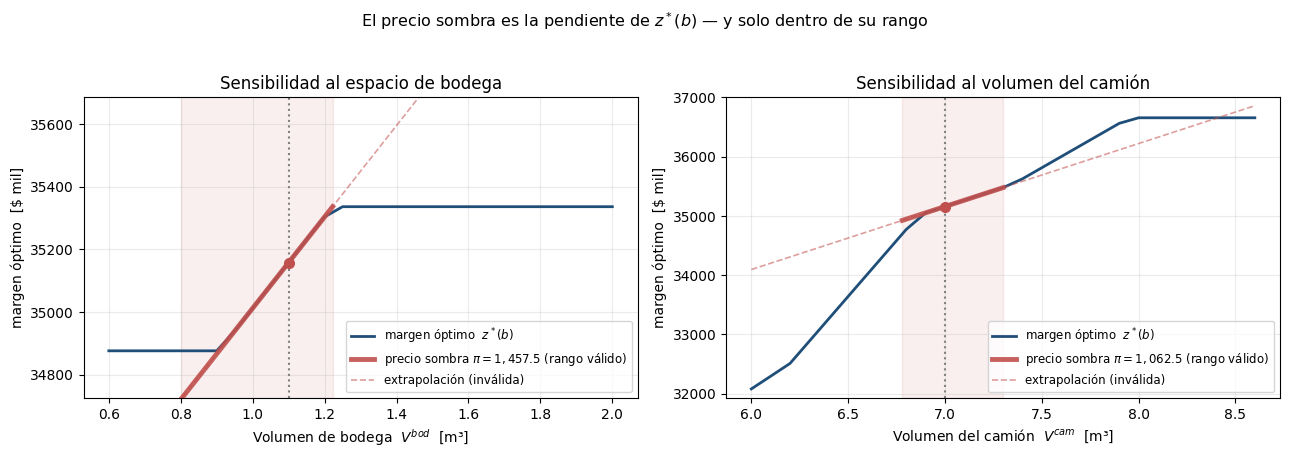

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))

for a, grid, base, c_, lab in [
        (ax[0], np.linspace(0.6, 2.0, 29), D["Vbod"], c_bod, "Volumen de bodega  $V^{bod}$"),
        (ax[1], np.linspace(6.0, 8.6, 27), D["Vcam"], c_vol, "Volumen del camión  $V^{cam}$")]:
    par = "Vbod" if c_ is c_bod else "Vcam"
    obj = [resolver(D, **{par: float(b)}).ObjVal for b in grid]
    a.plot(grid, obj, lw=2, color="#1f4e79", label="margen óptimo  $z^*(b)$")
    a.axvline(base, ls=":", color="gray")
    a.plot([base], [m.ObjVal], "o", color="#c0504d", ms=7, zorder=5)
    lo, hi = max(c_.SARHSLow, grid[0]), min(c_.SARHSUp, grid[-1])
    a.plot([lo, hi], [m.ObjVal + c_.Pi*(lo-base), m.ObjVal + c_.Pi*(hi-base)],
           lw=3.5, color="#c0504d", alpha=.9,
           label=f"precio sombra $\\pi={c_.Pi:,.1f}$ (rango válido)")
    a.axvspan(lo, hi, color="#c0504d", alpha=.09)
    a.plot(grid, m.ObjVal + c_.Pi*(grid-base), ls="--", lw=1.2, color="#c0504d", alpha=.55,
           label="extrapolación (inválida)")
    a.set_xlabel(lab + "  [m³]"); a.set_ylabel(r"margen óptimo  [\$ mil]")
    a.set_ylim(min(obj)-150, max(obj)+350); a.grid(alpha=.25)
    a.legend(fontsize=8.5, loc="lower right")

ax[0].set_title("Sensibilidad al espacio de bodega")
ax[1].set_title("Sensibilidad al volumen del camión")
fig.suptitle("El precio sombra es la pendiente de $z^*(b)$ — y solo dentro de su rango",
             y=1.03, fontsize=11.5)
plt.tight_layout(); plt.show()

**Dentro del rango el precio sombra es exacto.**

- Bodega, $\pi=1.457{,}5$ válido en $V^{bod}\in[0{,}800,\;1{,}222]$: $+0{,}05$ m³ → predicción $1.457{,}5\times0{,}05=72{,}875$, real $72{,}88$. Hasta el borde $1{,}222$ → predicción $178{,}14$, real $178{,}14$. **Exacto, hasta el último punto del rango.**
- Camión, $\pi=1.062{,}5$ válido en $V^{cam}\in[6{,}780,\;7{,}300]$: $+0{,}1$ m³ → $106{,}25$ predicho y real; hasta el borde $7{,}3$ → $318{,}75$ predicho y real. **Exacto.**

**Fuera del rango la predicción falla — y en un MIP puede fallar para los dos lados.**

- Bodega $+0{,}4$ m³ → predicción $583{,}00$, real **$178{,}14$**: la predicción sobreestima $3{,}3$ veces. Y $+2{,}0$ m³ da **lo mismo** ($178{,}14$): pasado $1{,}222$ m³ la bodega **deja de ser el cuello de botella**, porque se agota la capacidad de tostado de $t_1$ que permitía producir por adelantado. Ampliar la bodega más allá de eso no sirve para nada.
- Camión $+1{,}0$ m³ → predicción $1.062{,}50$, real **$1.496{,}75$**: aquí la predicción se queda **corta**. La razón es que con más caja el modelo **cambia la decisión discreta** y habilita también el turno extra en $t_2$ ($y^*$ pasa de $(0,0,1)$ a $(0,1,1)$), lo que abre una posibilidad que el LP con $y$ fija no podía ver.

Esa asimetría es importante. En un LP puro $z^*(b)$ es **cóncava**, así que el precio sombra siempre **sobreestima** fuera del rango. En un MIP, $z^*(b)$ es el máximo de varias funciones cóncavas (una por cada valor de $y$) y **ya no es cóncava**: el precio sombra del LP con $y$ fija puede quedar por debajo del verdadero salto. En el gráfico se ve: el panel de la izquierda se aplana (concavidad clásica) y el de la derecha tiene un tramo que **se empina** cuando se enciende el segundo turno.

> **Regla de negocio.** El precio sombra responde *"¿cuánto vale un poquito más de este recurso?"*. Para *"¿cuánto vale duplicarlo?"* hay una sola respuesta honesta: **volver a resolver el modelo.**

### ¿Y si nos ofrecen 600 kg más de carga útil? (pregunta 11)

**Recomendación: no pagar nada por eso.** El precio sombra de `peso` es $0$ en las tres semanas, con holguras de $1.400$, $600$ y $360$ kg, y el experimento lo confirma: $W=3.000$ deja el margen **idéntico** ($\Delta=0$).

La razón está en el **envase**. El Espresso Cumbre va en bolsas de 250 g: $\nu=0{,}0045$ m³/kg, así que los $7$ m³ del camión se llenan con apenas $1.556$ kg de ESP, muy por debajo de los $2.400$ kg de carga útil. Con el despacho mixto que hace el modelo en $t_3$ ($950$ kg de ESP + $1.090$ de INT), el camión toca el techo de volumen con $360$ kg de peso todavía disponibles. **Este camión se llena por volumen, no por peso.**

Lo que hay que pedirle al proveedor es **una caja más grande**: cada m³ adicional vale hasta \$1.062,5 mil.

> **¿Y entonces para qué escribimos la restricción de masa?** Porque no lo sabíamos antes de resolver, y porque con otra mezcla la respuesta cambia: un camión cargado **solo** con Intenso Patagón (sacos de 1 kg, $\nu=0{,}0025$) admite $2.800$ kg por volumen pero solo $2.400$ por peso — ahí **apretaría la masa**. Se escriben las dos y el modelo decide cuál manda.

### ¿Conviene arrendar un segundo camión en la semana 3? (pregunta 12)

Esta es la pregunta donde el precio sombra **no sirve**: un camión más cambia $nc_3$ de $1$ a $2$, o sea suma $7$ m³ de golpe — cuarenta veces el ancho del rango de validez.

In [12]:
pred = c_vol.Pi*D["Vcam"] - D["ct"]
m2 = resolver(D, nc={1: 1, 2: 1, 3: 2})

print("SEGUNDO CAMION EN LA SEMANA 3")
print(f"  Estimacion con el precio sombra (INVALIDA):")
print(f"     Pi x V_cam - ct = {c_vol.Pi:,.1f} x {D['Vcam']} - {D['ct']} = {pred:,.2f}")
print(f"  Rango de validez de volumen[3]: [{c_vol.SARHSLow:.3f}, {c_vol.SARHSUp:.3f}] m3"
      f"  ->  un salto de +{D['Vcam']} m3 queda MUY afuera")
print(f"\n  Resolviendo de nuevo el MIP con nc_3 = 2:")
print(f"     margen = {m2.ObjVal:,.2f}   (base {m.ObjVal:,.2f})")
print(f"     ganancia NETA = {m2.ObjVal - m.ObjVal:,.2f}   (el arriendo de {D['ct']} ya esta descontado)")
print(f"     y* = { {t: int(round(m2._var['y'][t].X)) for t in T} }   <- cambio la decision discreta")
print(f"\n  El precio sombra sobreestima {pred/(m2.ObjVal-m.ObjVal):.1f} veces, pero acierta el signo:"
      f" CONVIENE arrendarlo.")

SEGUNDO CAMION EN LA SEMANA 3
  Estimacion con el precio sombra (INVALIDA):
     Pi x V_cam - ct = 1,062.5 x 7.0 - 600 = 6,837.50
  Rango de validez de volumen[3]: [6.780, 7.300] m3  ->  un salto de +7.0 m3 queda MUY afuera

  Resolviendo de nuevo el MIP con nc_3 = 2:
     margen = 36,055.00   (base 35,158.25)
     ganancia NETA = 896.75   (el arriendo de 600 ya esta descontado)
     y* = {1: 0, 2: 1, 3: 1}   <- cambio la decision discreta

  El precio sombra sobreestima 7.6 veces, pero acierta el signo: CONVIENE arrendarlo.


La estimación ingenua sería $\pi\times V^{cam}-ct=1.062{,}5\times7-600=6.837{,}50$. **Absurda**: el rango de `volumen[3]` es $[6{,}78,\;7{,}30]$, es decir $\pm0{,}3$ m³ alrededor del punto base.

Resolviendo de nuevo con $nc_3=2$: el margen sube a $36.055{,}00$, una ganancia **neta de $896{,}75$** (el arriendo de $600$ ya está descontado dentro de la objetivo). El precio sombra sobreestima **7,6 veces**, pero **acierta el signo: conviene arrendarlo**.

Y aparece un efecto en cadena que los duales no podían anticipar: con más capacidad de despacho en $t_3$, el modelo también **habilita el turno extra en $t_2$** para alimentar esa venta adicional ($y^*$ pasa a $(0,1,1)$). Ese es el uso legítimo del precio sombra en un MIP: **señal de dónde mirar**, nunca cifra para el *business case*.

### ¿Conviene habilitar el turno extra en $t_1$ o $t_2$? (pregunta 13)

Tampoco se puede responder con los duales, y por una razón de fondo: **la binaria está fija en el LP**. Preguntar por $y_t$ es preguntar por otro problema entero. La respuesta se obtiene forzando la binaria y resolviendo.

In [13]:
print("Forzando la binaria y resolviendo de nuevo:")
for t in T:
    mf = construir_modelo(D)
    if ystar[t] == 0:
        mf._var["y"][t].LB = 1; accion = f"habilitar el turno en t{t}"
    else:
        mf._var["y"][t].UB = 0; accion = f"NO habilitar el turno en t{t}"
    mf.optimize()
    tostado = sum(mf._var["x"][g,i,t].X for g in G for i in I)
    print(f"  {accion:<32} margen = {mf.ObjVal:10,.2f}   delta = {mf.ObjVal-m.ObjVal:+9,.2f}"
          f"   (tostado en t{t}: {tostado:.0f} kg)")

Forzando la binaria y resolviendo de nuevo:
  habilitar el turno en t1         margen =  34,658.25   delta =   -500.00   (tostado en t1: 1440 kg)
  habilitar el turno en t2         margen =  34,876.39   delta =   -281.86   (tostado en t2: 1900 kg)
  NO habilitar el turno en t3      margen =  34,753.88   delta =   -404.38   (tostado en t3: 1500 kg)


**Los tres resultados.**

- **Habilitar el turno en $t_1$: $-500{,}00$.** El modelo abre el turno, **paga los \$500 mil y no lo usa** (sigue tostando $1.440$ kg, por debajo de los $1.500$ del turno normal). No lo usa porque lo que produjera de más no tendría dónde ir: la bodega ya está llena al cierre de $t_1$. Pérdida limpia del costo fijo.
- **Habilitar el turno en $t_2$: $-281{,}86$.** Aquí sí lo usa —tuesta $1.900$ kg— pero los kilos extra rinden $218{,}14$, menos que los $500$ que cuesta habilitarlo. **Está bien que el óptimo diga que no.**
- **Prohibir el turno en $t_3$: $-404{,}38$.** El turno extra de $t_3$ aporta $404{,}38$ netos. Bien habilitado.

Fíjese en la diferencia con el análisis de sensibilidad: `tostado[2]` tiene precio sombra $3{,}744$ por kg, y el turno agrega $400$ kg, lo que sugeriría $3{,}744\times400=1.497{,}5$ de ganancia. El valor real es $218{,}14$. Otra vez el rango: `tostado[2]` es válido hasta $1.548{,}9$ kg, o sea **$+48{,}9$ kg**, no $+400$. $3{,}744\times48{,}9\approx183$ ya está en el orden correcto.

> **Moraleja.** Un precio sombra **por unidad** no se multiplica por un salto **discreto**. Las decisiones binarias —abrir un turno, arrendar un camión, instalar una máquina— se evalúan **resolviendo el modelo dos veces** y comparando, nunca extrapolando duales.

---

## Resumen

| Estructura | Forma correcta | Error típico |
|:--|:--|:--|
| **Proporciones** | $x_{git}\le\bar\alpha_{gi}\sum_{g'}x_{g'it}$ | escribirla como cociente (no lineal, indefinida en $0$) |
| **Balance de inventario** | igualdad, con el **dato** $r^0_i$ en el primer periodo | usar $\le$, u olvidar el inventario inicial |
| **Activación Big-M** | $\sum\sum x_{git}\le K+M y_t$ con **$M=K^{ex}$**, la cota válida más chica | poner $M=10^9$ y arruinar la relajación lineal |
| **Masa y volumen** | **dos** restricciones; el modelo decide cuál aprieta | modelar solo una y prometer despachos imposibles |

| Sensibilidad | Idea | Cómo se opera |
|:--|:--|:--|
| **Un MIP no tiene duales** | mientras haya binarias libres, $z^*(b)$ no es cóncava | resolver el MIP → **fijar $y^*$** → LP (`m.fixed()` o reconstruir) |
| **Precio sombra** | $\pi_i=\partial z^*/\partial b_i$ | `.Pi` de la restricción en el LP fijado |
| **Holgura complementaria** | $\pi_i\cdot\text{Slack}_i=0$ | recurso con holgura ⟹ $\pi=0$ (la masa del camión) |
| **Se calculan a mano** | variable positiva ⟹ restricción dual activa | sistema $2\times2$: $\text{margen}_i=\pi_{\text{tostado}}+\nu_i\pi_{\text{volumen}}$ |
| **Rango de validez** | $\pi$ constante solo en $[b^{low},b^{up}]$ | `.SARHSLow`/`.SARHSUp`; fuera del rango, **volver a resolver** |
| **Saltos discretos** | un turno, un camión: no son "una unidad más" | forzar la binaria y resolver de nuevo |

$$\boxed{\;\text{margen}^*=35.158{,}25\quad y^*=(0,0,1)\quad \pi_{\text{bodega}[1]}=1.457{,}5\quad \pi_{\text{volumen}[3]}=1.062{,}5\quad \pi_{\text{peso}}=0\;}$$

**La idea para llevarse.** Un modelo bien planteado no entrega solo un plan: entrega el **precio de cada recurso escaso** de la empresa —la bodega vale \$1.457,5 el m³, la caja del camión \$1.062,5, la carga útil nada—. Ese es el producto más valioso de la optimización, y también el más fácil de citar mal: **siempre con su rango de validez**.

---
*Ayudantía 7 — IIP314W Optimización Aplicada a Negocios — Universidad del Desarrollo — 2026-T2*